In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from PIL import Image
import os
from collections import Counter, defaultdict
import random
import networkx as nx
from matplotlib.patches import ConnectionPatch

# Set style
plt.style.use('default')
%matplotlib inline

## 1. Load dữ liệu PSG

In [2]:
# Đường dẫn đến dữ liệu
PSG_ROOT = 'datasets/psg'
PSG_JSON = os.path.join(PSG_ROOT, 'psg/psg.json')
COCO_IMAGES = os.path.join(PSG_ROOT, 'coco/coco')
OBJ_CLASSES_FILE = os.path.join(PSG_ROOT, 'obj_classes.txt')
PRED_CLASSES_FILE = 'psg_predicates_list.json'

# Load PSG annotations
print("Loading PSG annotations...")
with open(PSG_JSON, 'r') as f:
    psg_data = json.load(f)

print(f"Total images: {len(psg_data['data'])}")
print(f"Keys in data: {list(psg_data.keys())}")

Loading PSG annotations...
Total images: 48749
Keys in data: ['data', 'thing_classes', 'stuff_classes', 'predicate_classes', 'test_image_ids']


In [3]:
# Load object classes
with open(OBJ_CLASSES_FILE, 'r') as f:
    obj_classes = [line.strip() for line in f.readlines()]

print(f"Number of object classes: {len(obj_classes)}")
print(f"First 10 classes: {obj_classes[:10]}")

Number of object classes: 133
First 10 classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


In [4]:
# Load predicate classes
with open(PRED_CLASSES_FILE, 'r') as f:
    pred_classes = json.load(f)

print(f"Number of predicate classes: {len(pred_classes)}")
print(f"First 10 predicates: {pred_classes[:10]}")

Number of predicate classes: 57
First 10 predicates: ['__background__', 'over', 'in front of', 'beside', 'on', 'in', 'attached to', 'hanging from', 'on back of', 'falling off']


## 2. Hàm vẽ Scene Graph dạng Network

In [5]:
def draw_scene_graph(img_data, ax, max_nodes=30, max_edges=40):
    """
    Vẽ scene graph dạng network với networkx
    
    Args:
        img_data: Dictionary chứa thông tin ảnh từ PSG dataset
        ax: Matplotlib axis để vẽ
        max_nodes: Số lượng nodes tối đa
        max_edges: Số lượng edges tối đa
    """
    # Create directed graph
    G = nx.MultiDiGraph()
    
    # Limit annotations
    annotations = img_data['annotations'][:max_nodes]
    
    # Add nodes with attributes
    node_labels = {}
    for idx, ann in enumerate(annotations):
        category_id = ann['category_id']
        class_name = obj_classes[category_id] if category_id < len(obj_classes) else f'ID_{category_id}'
        
        G.add_node(idx, label=class_name, category=category_id)
        node_labels[idx] = f"{idx}_{class_name}"
    
    # Add edges (relationships)
    edge_labels = {}
    edges_added = 0
    
    for rel in img_data.get('relations', []):
        if edges_added >= max_edges:
            break
            
        subj_idx, obj_idx, pred_id = rel
        
        # Only add if both nodes exist
        if subj_idx < len(annotations) and obj_idx < len(annotations):
            pred_name = pred_classes[pred_id] if pred_id < len(pred_classes) else f'pred_{pred_id}'
            
            G.add_edge(subj_idx, obj_idx, predicate=pred_name)
            edge_labels[(subj_idx, obj_idx)] = pred_name
            edges_added += 1
    
    # Layout - use different layouts based on graph size
    if len(G.nodes()) < 15:
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    else:
        pos = nx.kamada_kawai_layout(G)
    
    # Draw nodes
    node_colors = plt.cm.Set3(np.linspace(0, 1, len(G.nodes())))
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                          node_color=node_colors,
                          node_size=2000,
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=2)
    
    # Draw edges with curved arrows
    for edge in G.edges():
        start_node, end_node = edge
        
        # Calculate control point for curved arrow
        start_pos = pos[start_node]
        end_pos = pos[end_node]
        
        # Add curvature
        rad = 0.3
        
        arrow = FancyArrowPatch(
            start_pos, end_pos,
            arrowstyle='-|>',
            connectionstyle=f"arc3,rad={rad}",
            mutation_scale=25,
            linewidth=2,
            color='darkblue',
            alpha=0.6,
            zorder=1
        )
        ax.add_patch(arrow)
    
    # Draw node labels
    for node, (x, y) in pos.items():
        label = node_labels[node]
        ax.text(x, y, label, 
               fontsize=9,
               ha='center', 
               va='center',
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', 
                        facecolor='white', 
                        edgecolor='black',
                        linewidth=1.5,
                        alpha=0.9),
               zorder=2)
    
    # Draw edge labels (predicates)
    edge_labels_drawn = {}
    for (start, end), label in edge_labels.items():
        if (start, end) not in edge_labels_drawn:
            start_pos = pos[start]
            end_pos = pos[end]
            
            # Calculate midpoint with offset for curved edge
            mid_x = (start_pos[0] + end_pos[0]) / 2
            mid_y = (start_pos[1] + end_pos[1]) / 2
            
            # Offset perpendicular to edge
            dx = end_pos[0] - start_pos[0]
            dy = end_pos[1] - start_pos[1]
            norm = np.sqrt(dx**2 + dy**2)
            if norm > 0:
                offset_x = -dy / norm * 0.1
                offset_y = dx / norm * 0.1
            else:
                offset_x, offset_y = 0, 0
            
            ax.text(mid_x + offset_x, mid_y + offset_y, label,
                   fontsize=7,
                   ha='center',
                   va='center',
                   bbox=dict(boxstyle='round,pad=0.2',
                            facecolor='yellow',
                            edgecolor='orange',
                            alpha=0.8,
                            linewidth=1),
                   zorder=3)
            
            edge_labels_drawn[(start, end)] = True
    
    ax.axis('off')
    ax.set_title('Scene Graph', fontsize=12, fontweight='bold', pad=10)

## 3. Hàm trực quan hóa đầy đủ (Ảnh + Bounding Boxes + Scene Graph)

In [6]:
def visualize_complete_scene(img_data, max_relations=30):
    """
    Trực quan hóa đầy đủ: ảnh với bounding boxes + scene graph
    
    Args:
        img_data: Dictionary chứa thông tin ảnh từ PSG dataset
        max_relations: Số lượng relationships tối đa để hiển thị
    """
    # Load image
    img_path = os.path.join(COCO_IMAGES, img_data['file_name'])
    
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return
    
    img = Image.open(img_path)
    img_array = np.array(img)
    
    # Create figure with two subplots
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    # Left: Image with bounding boxes
    ax1.imshow(img_array)
    
    # Generate colors for each object
    num_objects = len(img_data['annotations'])
    colors = plt.cm.tab20(np.linspace(0, 1, max(num_objects, 20)))
    
    # Draw bounding boxes
    for idx, ann in enumerate(img_data['annotations'][:30]):
        bbox = ann['bbox']
        category_id = ann['category_id']
        
        # Get class name
        class_name = obj_classes[category_id] if category_id < len(obj_classes) else f'ID_{category_id}'
        
        # Calculate bbox parameters
        x, y, x2, y2 = bbox
        width = x2 - x
        height = y2 - y
        
        # Draw bounding box
        color = colors[idx % len(colors)]
        rect = patches.Rectangle((x, y), width, height, 
                                linewidth=3, edgecolor=color, 
                                facecolor='none', linestyle='-')
        ax1.add_patch(rect)
        
        # Add label
        label = f'{idx}_{class_name}'
        ax1.text(x, y - 5, label, 
               bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.8),
               fontsize=10, color='white', weight='bold')
    
    # Set title for image
    title = f"Image: {img_data['file_name']}\n"
    title += f"Objects: {len(img_data['annotations'])}, Relations: {len(img_data.get('relations', []))}"
    ax1.set_title(title, fontsize=12, weight='bold')
    ax1.axis('off')
    
    # Right: Scene Graph
    draw_scene_graph(img_data, ax2, max_nodes=30, max_edges=max_relations)
    
    plt.tight_layout()
    plt.show()
    
    # Print relationships
    print("\nRelationships (Subject -> Predicate -> Object):")
    print("="*80)
    relations_to_show = img_data['relations'][:max_relations]
    
    for i, rel in enumerate(relations_to_show, 1):
        subj_idx, obj_idx, pred_id = rel
        if subj_idx < len(img_data['annotations']) and obj_idx < len(img_data['annotations']):
            subj_class = obj_classes[img_data['annotations'][subj_idx]['category_id']]
            obj_class = obj_classes[img_data['annotations'][obj_idx]['category_id']]
            pred_name = pred_classes[pred_id] if pred_id < len(pred_classes) else f'pred_{pred_id}'
            print(f"{i:3d}. [{subj_idx}] {subj_class:15s} --[{pred_name:15s}]--> [{obj_idx}] {obj_class}")
    
    if len(img_data['relations']) > max_relations:
        print(f"\n... and {len(img_data['relations']) - max_relations} more relationships")

## 4. Hàm vẽ Scene Graph độc lập (không có ảnh)

In [7]:
def visualize_graph_only(img_data, max_nodes=30, max_edges=50, figsize=(16, 12)):
    """
    Chỉ vẽ scene graph, không hiển thị ảnh
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Draw scene graph
    draw_scene_graph(img_data, ax, max_nodes=max_nodes, max_edges=max_edges)
    
    # Add overall title
    title = f"Scene Graph: {img_data['file_name']}\n"
    title += f"Nodes: {min(len(img_data['annotations']), max_nodes)}, "
    title += f"Edges: {min(len(img_data.get('relations', [])), max_edges)}"
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 5. Thống kê Dataset

In [8]:
# Thống kê cơ bản
total_images = len(psg_data['data'])
total_objects = 0
total_relations = 0
objects_per_image = []
relations_per_image = []
object_class_counts = Counter()
predicate_counts = Counter()

for img_data in psg_data['data']:
    num_objects = len(img_data['annotations'])
    num_relations = len(img_data['relations'])
    
    objects_per_image.append(num_objects)
    relations_per_image.append(num_relations)
    total_objects += num_objects
    total_relations += num_relations
    
    for ann in img_data['annotations']:
        object_class_counts[ann['category_id']] += 1
    
    for rel in img_data['relations']:
        predicate_counts[rel[2]] += 1

print(f"Total images: {total_images}")
print(f"Total objects: {total_objects}")
print(f"Total relations: {total_relations}")
print(f"Average objects per image: {np.mean(objects_per_image):.2f}")
print(f"Average relations per image: {np.mean(relations_per_image):.2f}")

Total images: 48749
Total objects: 538153
Total relations: 275371
Average objects per image: 11.04
Average relations per image: 5.65


## 6. Ví dụ: Trực quan hóa ảnh với Scene Graph

Found 29546 images with at least 5 objects and 5 relations


/tmp/ipykernel_1456/1108512443.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


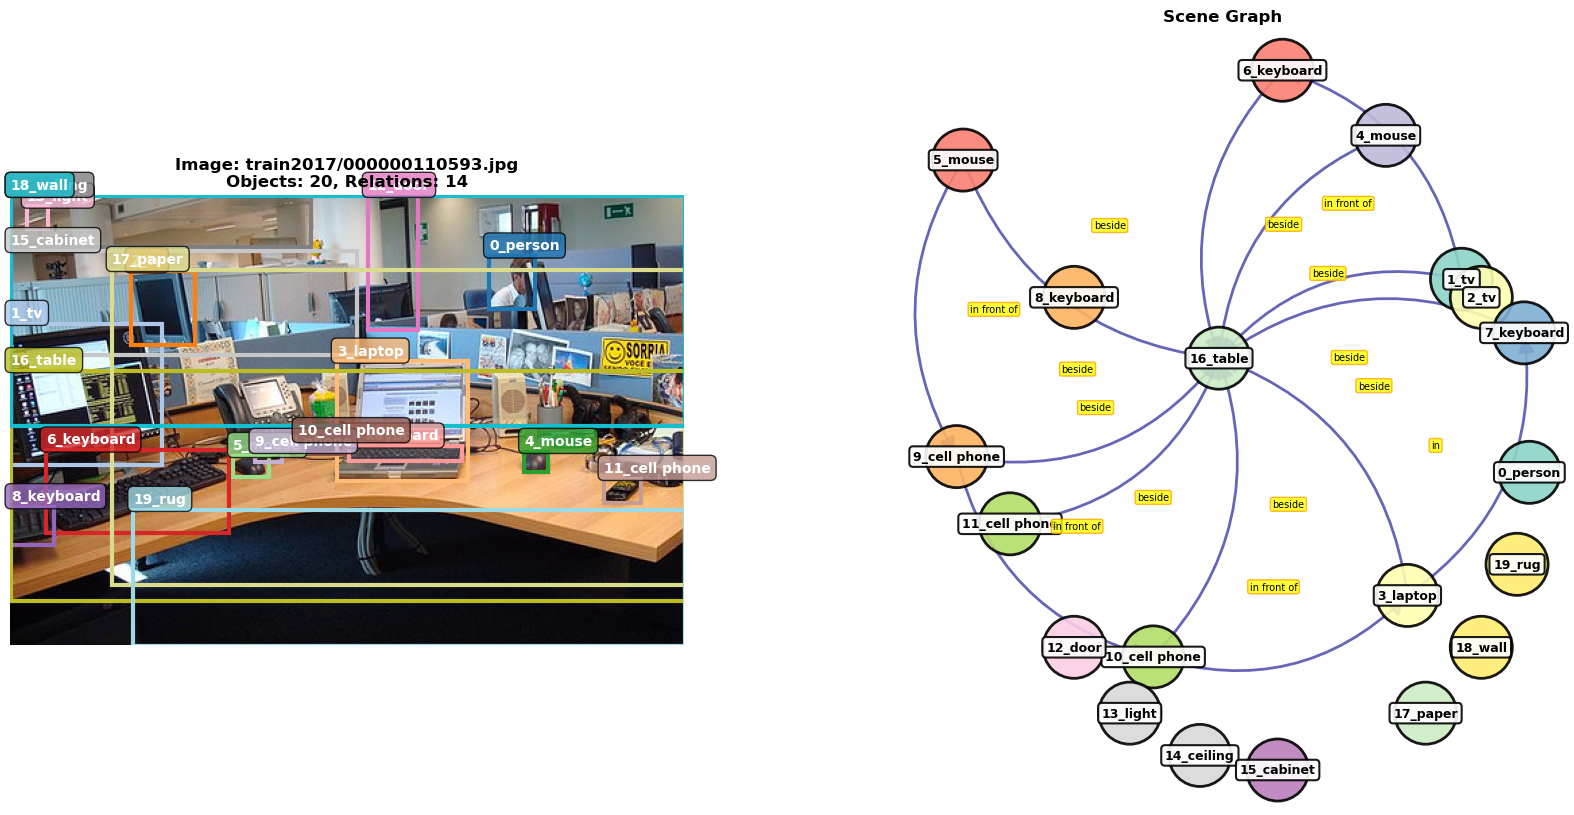


Relationships (Subject -> Predicate -> Object):
  1. [1] tv              --[in front of    ]--> [6] keyboard
  2. [1] tv              --[beside         ]--> [16] table
  3. [3] laptop          --[in             ]--> [7] keyboard
  4. [3] laptop          --[beside         ]--> [16] table
  5. [4] mouse           --[beside         ]--> [16] table
  6. [5] mouse           --[in front of    ]--> [9] cell phone
  7. [5] mouse           --[beside         ]--> [16] table
  8. [6] keyboard        --[beside         ]--> [16] table
  9. [7] keyboard        --[beside         ]--> [16] table
 10. [9] cell phone      --[in front of    ]--> [10] cell phone
 11. [9] cell phone      --[beside         ]--> [16] table
 12. [10] cell phone      --[in front of    ]--> [3] laptop
 13. [10] cell phone      --[beside         ]--> [16] table
 14. [11] cell phone      --[beside         ]--> [16] table


In [9]:
# Chọn ảnh có nhiều objects và relationships
good_images = [img for img in psg_data['data'] 
               if len(img['annotations']) >= 5 and len(img.get('relations', [])) >= 5]

print(f"Found {len(good_images)} images with at least 5 objects and 5 relations")

# Visualize một ảnh ngẫu nhiên
if good_images:
    sample_img = random.choice(good_images)
    visualize_complete_scene(sample_img, max_relations=30)

## 7. Ví dụ: Chỉ vẽ Scene Graph (không có ảnh)

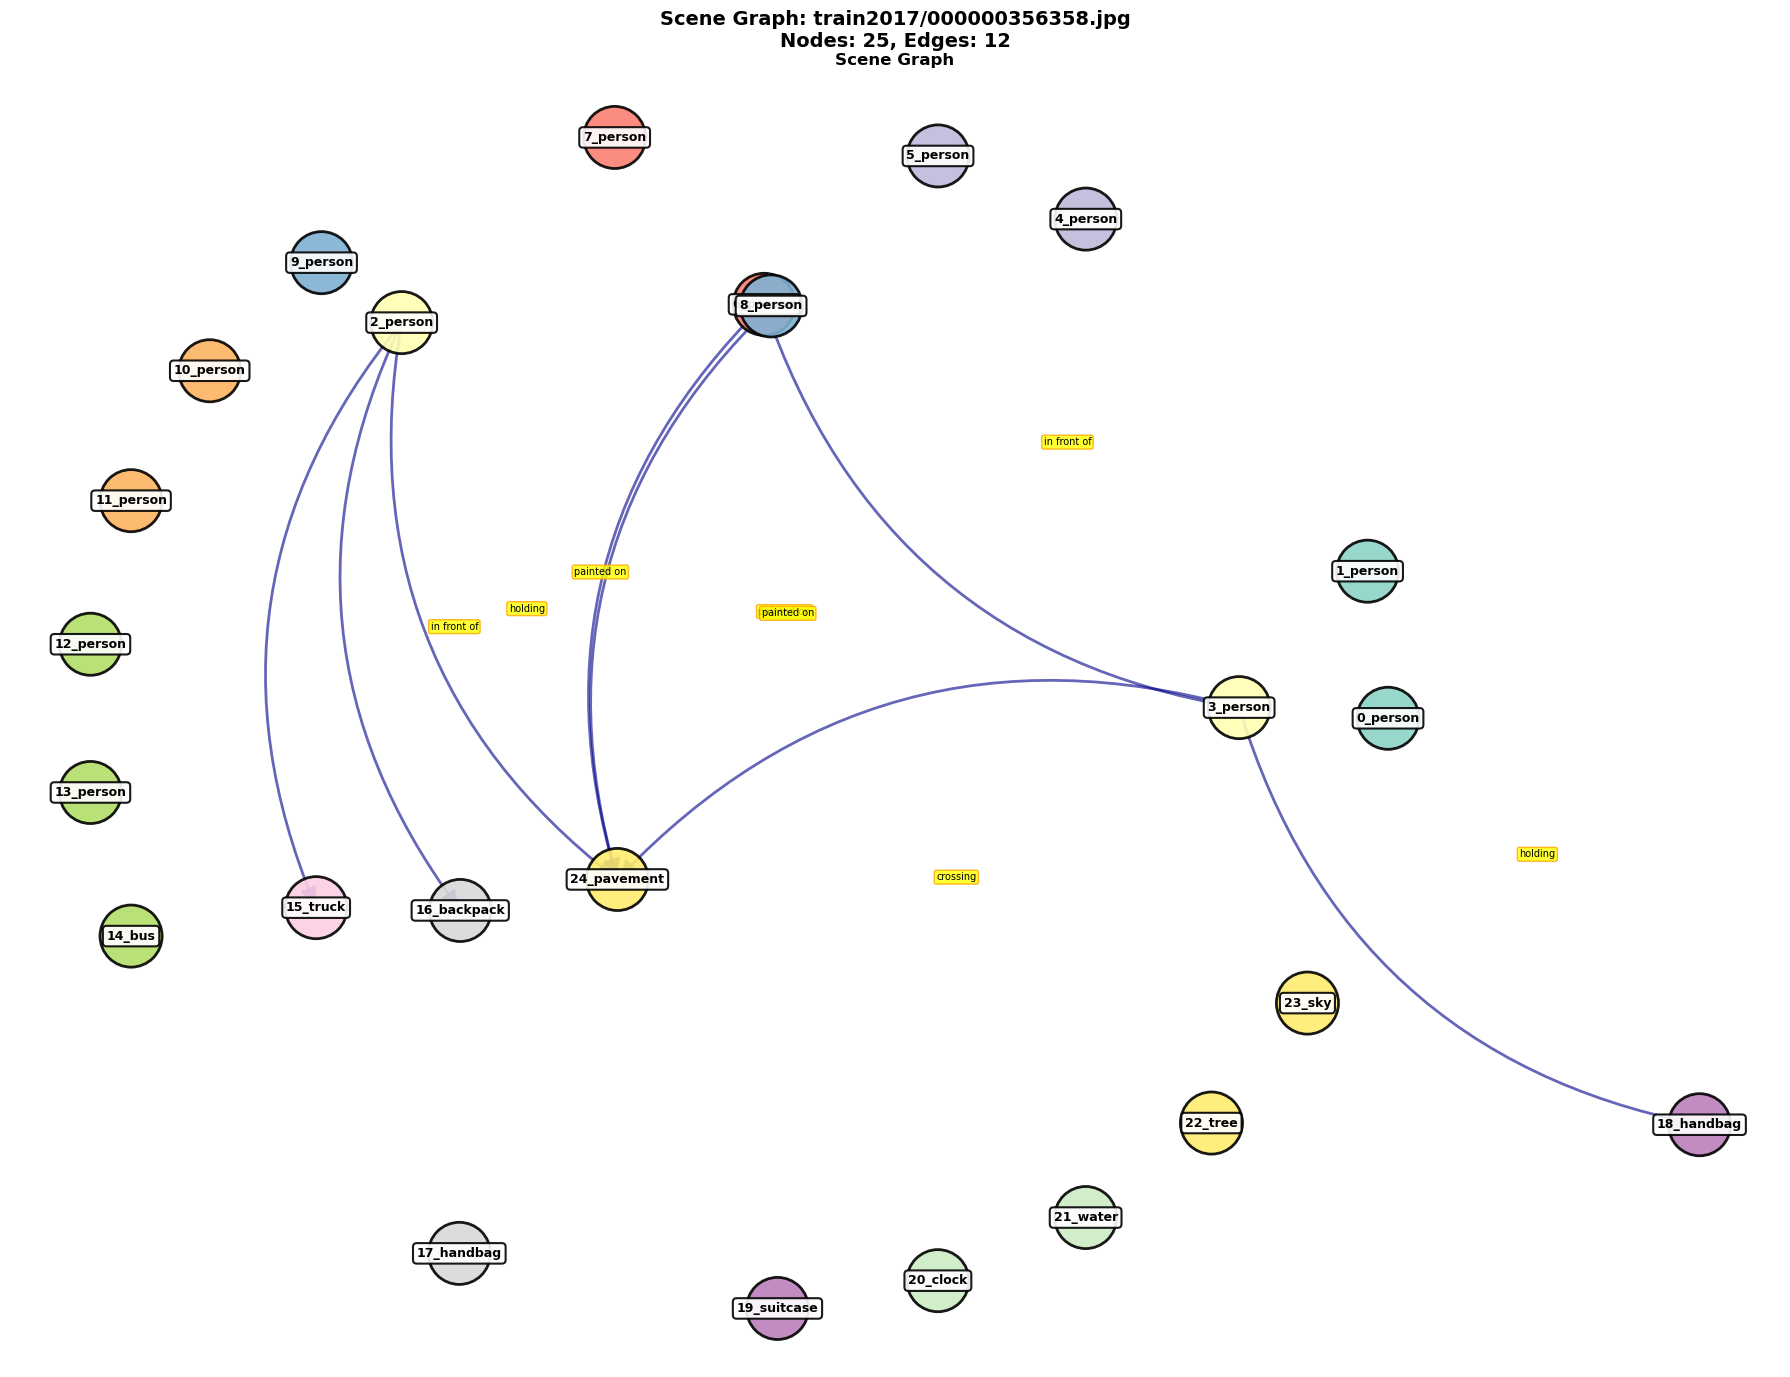

In [10]:
# Vẽ scene graph lớn hơn, rõ ràng hơn
if good_images:
    sample_img = random.choice(good_images)
    visualize_graph_only(sample_img, max_nodes=25, max_edges=40, figsize=(18, 14))

## 8. Visualize theo index

/tmp/ipykernel_1456/1108512443.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


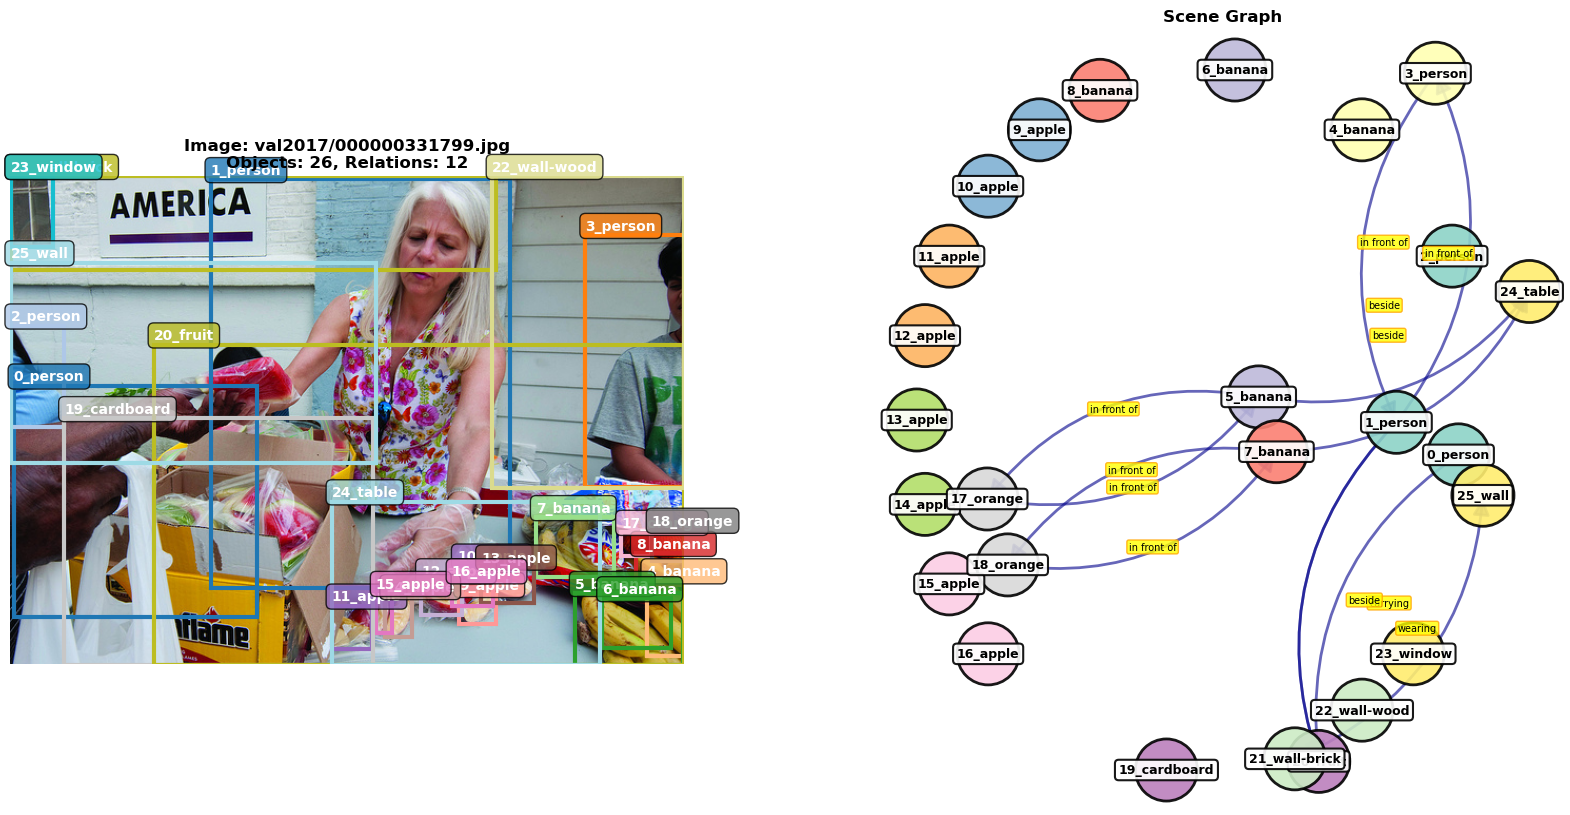


Relationships (Subject -> Predicate -> Object):
  1. [0] person          --[wearing        ]--> [20] fruit
  2. [1] person          --[in front of    ]--> [3] person
  3. [1] person          --[wearing        ]--> [20] fruit
  4. [1] person          --[carrying       ]--> [20] fruit
  5. [3] person          --[in front of    ]--> [1] person
  6. [5] banana          --[in front of    ]--> [17] orange
  7. [5] banana          --[beside         ]--> [24] table
  8. [7] banana          --[in front of    ]--> [18] orange
  9. [7] banana          --[beside         ]--> [24] table
 10. [17] orange          --[in front of    ]--> [5] banana
 11. [18] orange          --[in front of    ]--> [7] banana
 12. [21] wall-brick      --[beside         ]--> [25] wall


In [11]:
# Chọn index cụ thể
image_index = 5
visualize_complete_scene(psg_data['data'][image_index], max_relations=25)

## 9. Visualize nhiều ảnh


Sample 1/3


/tmp/ipykernel_1456/1108512443.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


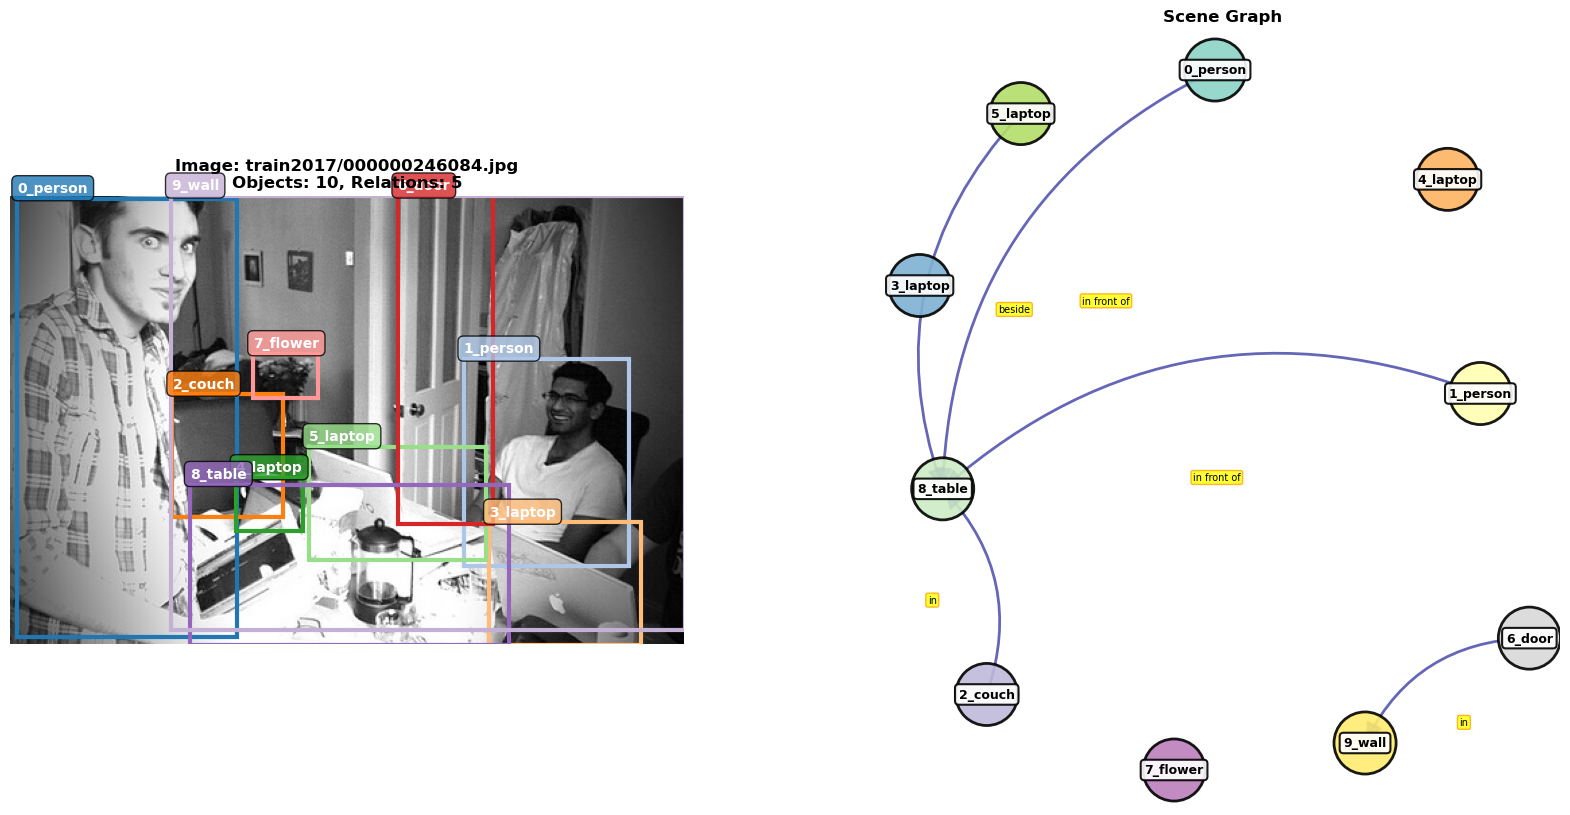


Relationships (Subject -> Predicate -> Object):
  1. [0] person          --[in front of    ]--> [8] table
  2. [1] person          --[in front of    ]--> [8] table
  3. [2] couch           --[in             ]--> [8] table
  4. [5] laptop          --[beside         ]--> [8] table
  5. [6] door            --[in             ]--> [9] wall

Sample 2/3


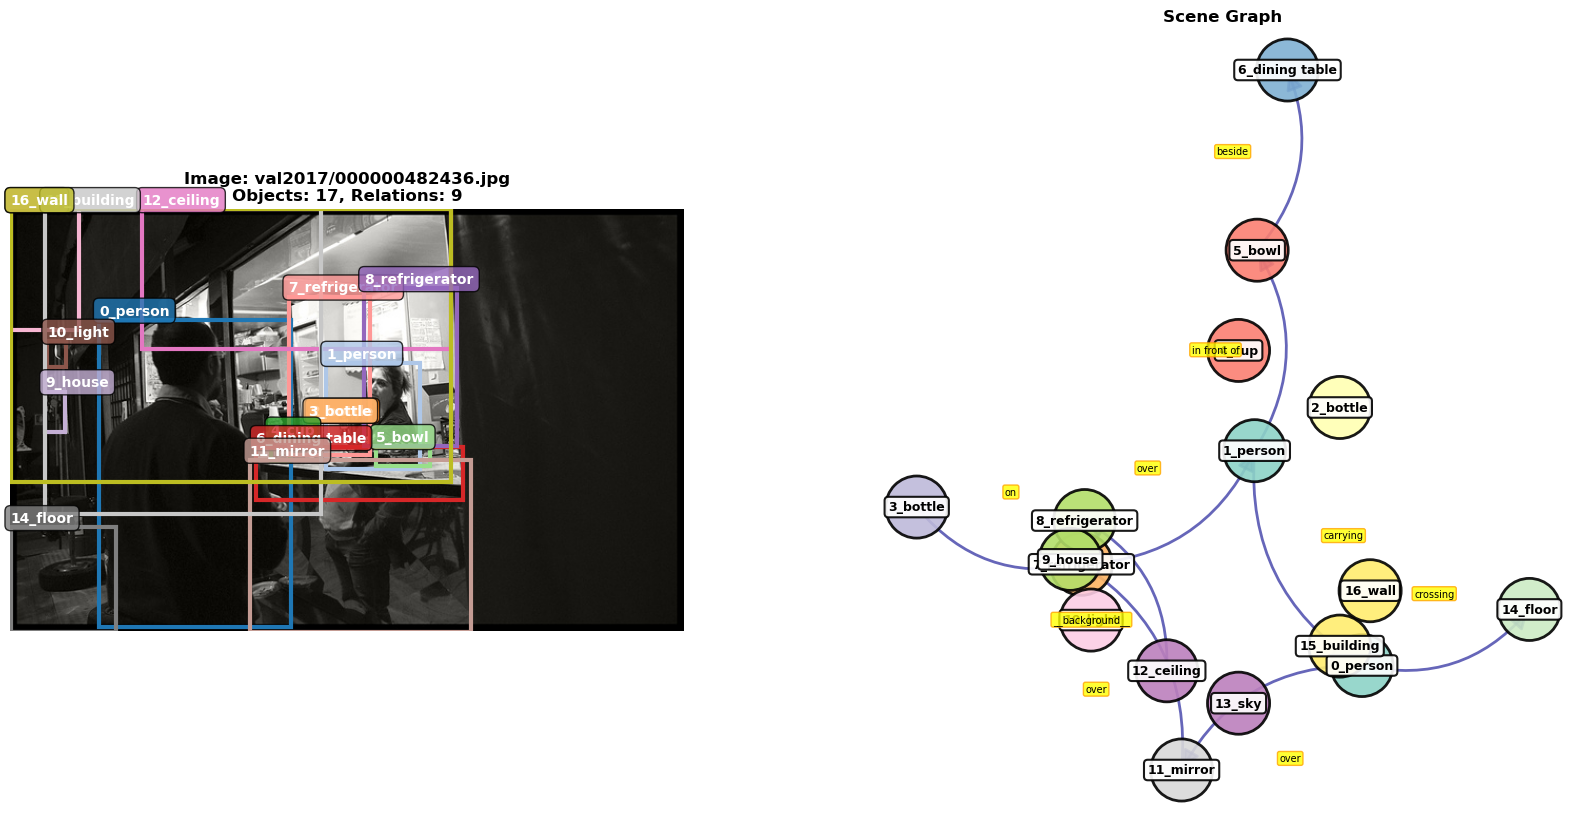


Relationships (Subject -> Predicate -> Object):
  1. [0] person          --[over           ]--> [11] mirror
  2. [0] person          --[crossing       ]--> [14] floor
  3. [1] person          --[carrying       ]--> [0] person
  4. [1] person          --[in front of    ]--> [5] bowl
  5. [3] bottle          --[on             ]--> [7] refrigerator
  6. [5] bowl            --[beside         ]--> [6] dining table
  7. [7] refrigerator    --[over           ]--> [1] person
  8. [11] mirror          --[over           ]--> [7] refrigerator
  9. [12] ceiling         --[__background__ ]--> [8] refrigerator

Sample 3/3


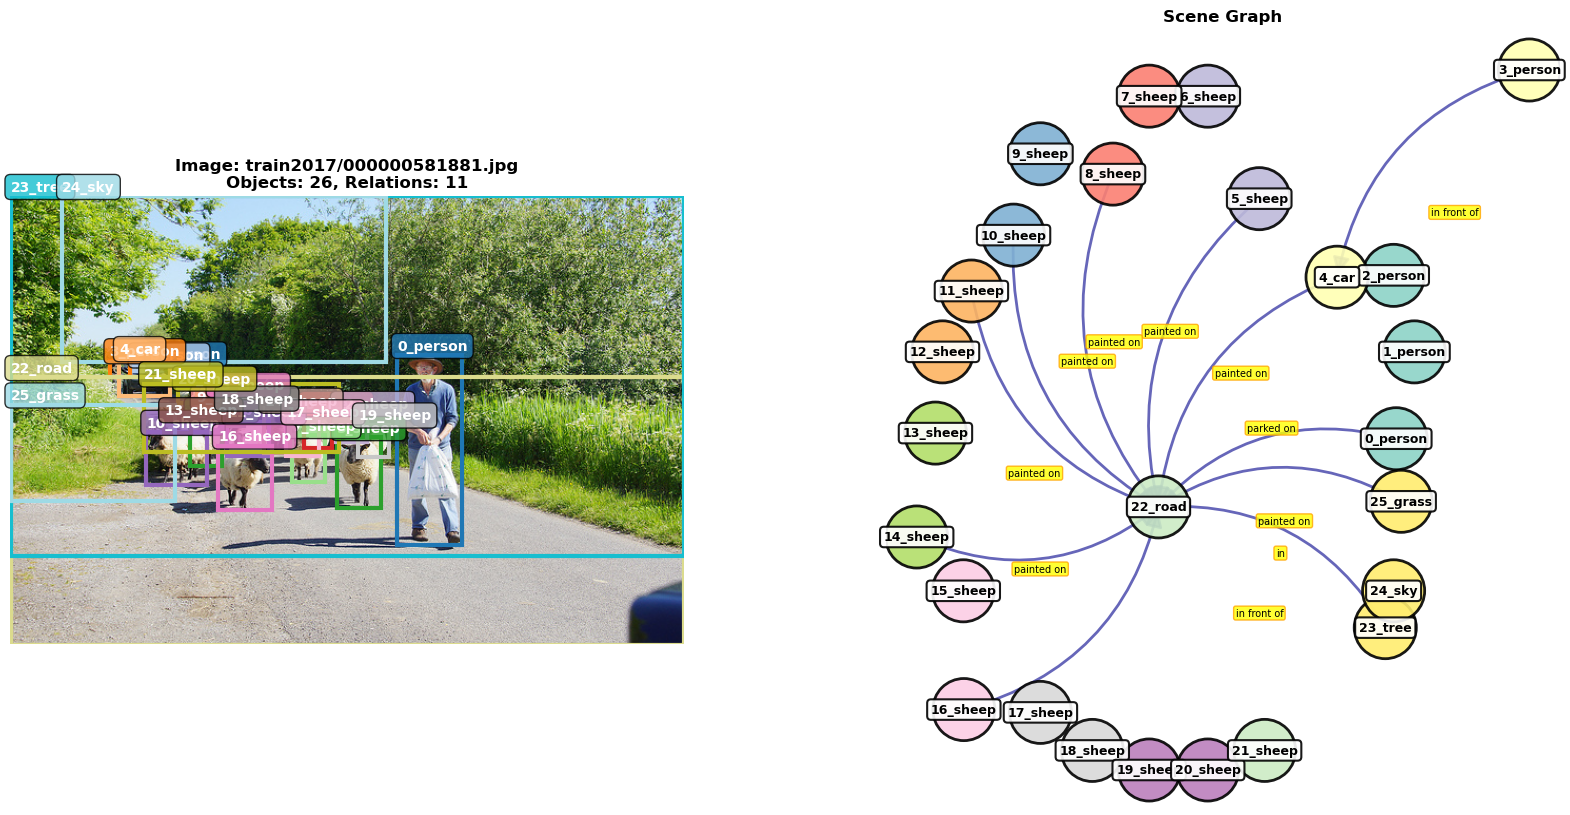


Relationships (Subject -> Predicate -> Object):
  1. [0] person          --[painted on     ]--> [22] road
  2. [3] person          --[in front of    ]--> [4] car
  3. [4] car             --[parked on      ]--> [22] road
  4. [5] sheep           --[painted on     ]--> [22] road
  5. [8] sheep           --[painted on     ]--> [22] road
  6. [10] sheep           --[painted on     ]--> [22] road
  7. [11] sheep           --[painted on     ]--> [22] road
  8. [14] sheep           --[painted on     ]--> [22] road
  9. [16] sheep           --[painted on     ]--> [22] road
 10. [23] tree            --[in front of    ]--> [22] road
 11. [25] grass           --[in             ]--> [22] road


In [12]:
# Visualize 3 ảnh ngẫu nhiên
num_samples = 3
sample_images = random.sample(good_images, min(num_samples, len(good_images)))

for i, img_data in enumerate(sample_images):
    print(f"\n{'='*100}")
    print(f"Sample {i+1}/{num_samples}")
    print(f"{'='*100}")
    visualize_complete_scene(img_data, max_relations=25)

## 10. So sánh nhiều Scene Graphs

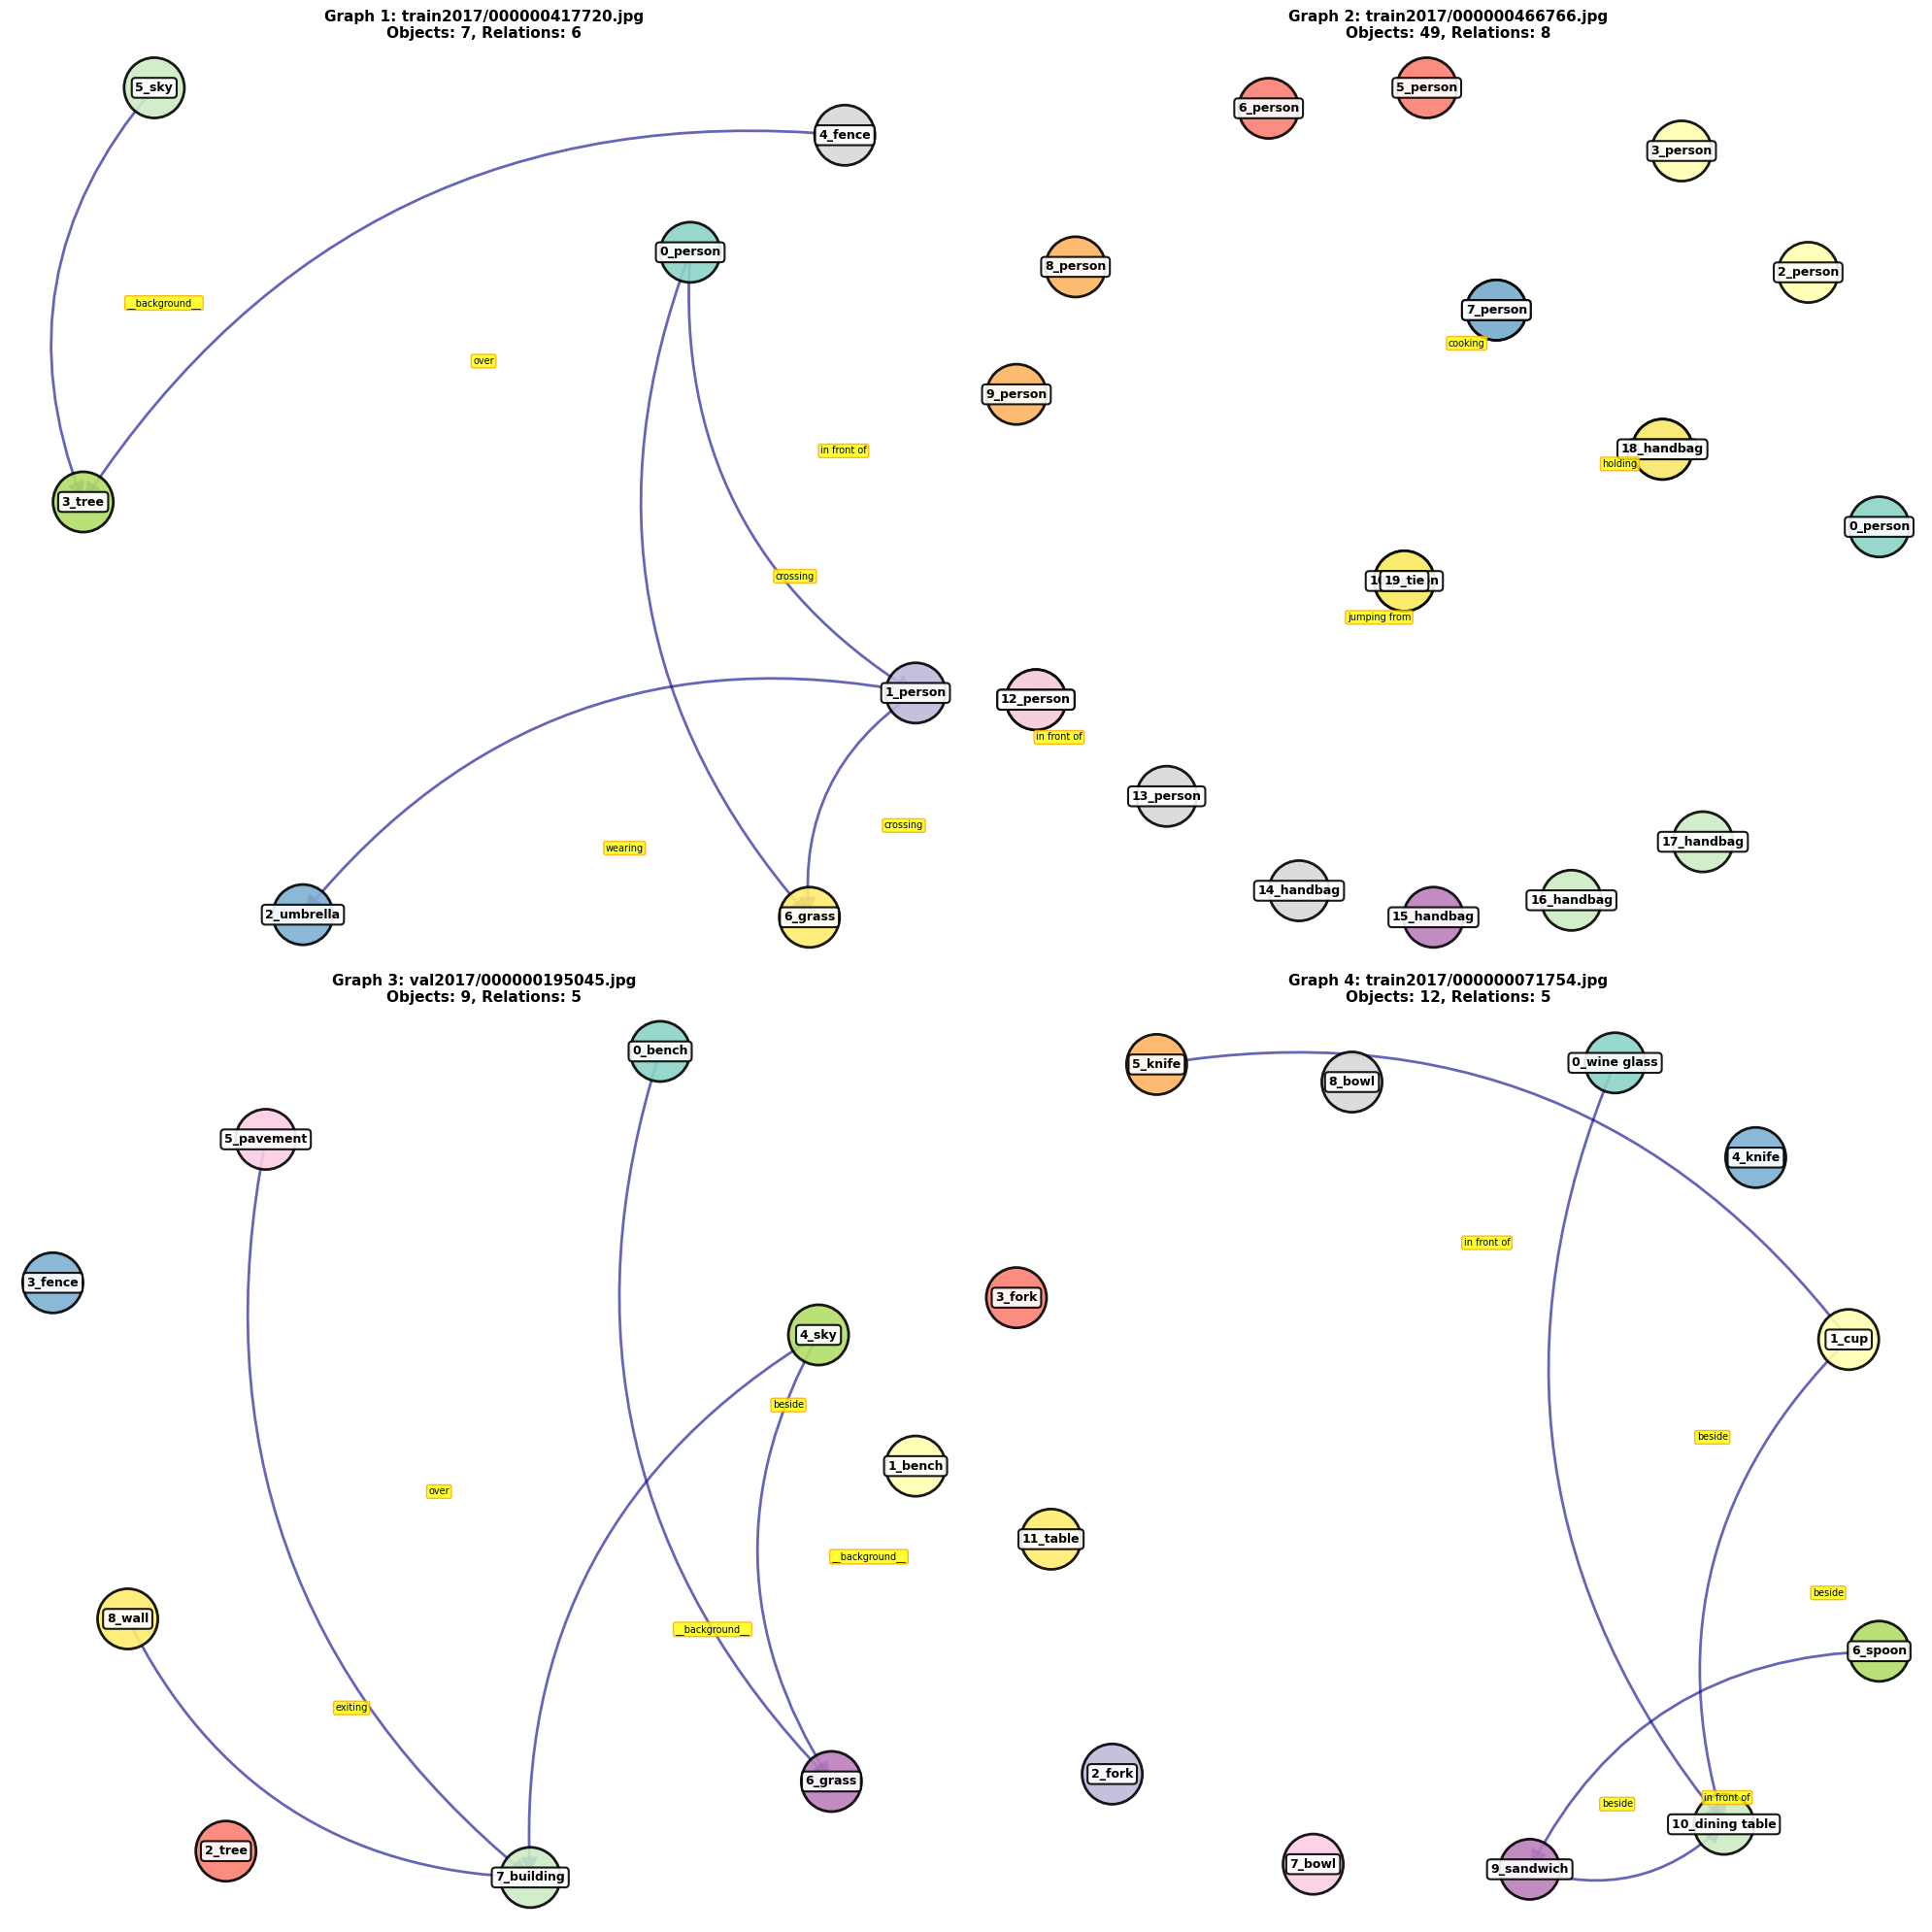

In [13]:
# Vẽ nhiều scene graphs trong cùng một figure
def compare_scene_graphs(images_data, num_graphs=4):
    """
    Vẽ nhiều scene graphs để so sánh
    """
    images_to_show = images_data[:num_graphs]
    
    # Calculate grid size
    cols = 2
    rows = (num_graphs + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 10 * rows))
    axes = axes.flatten() if num_graphs > 1 else [axes]
    
    for idx, (ax, img_data) in enumerate(zip(axes, images_to_show)):
        draw_scene_graph(img_data, ax, max_nodes=20, max_edges=25)
        ax.set_title(f"Graph {idx+1}: {img_data['file_name']}\n"
                    f"Objects: {len(img_data['annotations'])}, "
                    f"Relations: {len(img_data.get('relations', []))}",
                    fontsize=11, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(len(images_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Compare 4 random scene graphs
compare_scene_graphs(good_images, num_graphs=4)

## 11. Tìm kiếm và visualize theo predicate

Found 4047 images with predicate 'riding'


/tmp/ipykernel_1456/1108512443.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


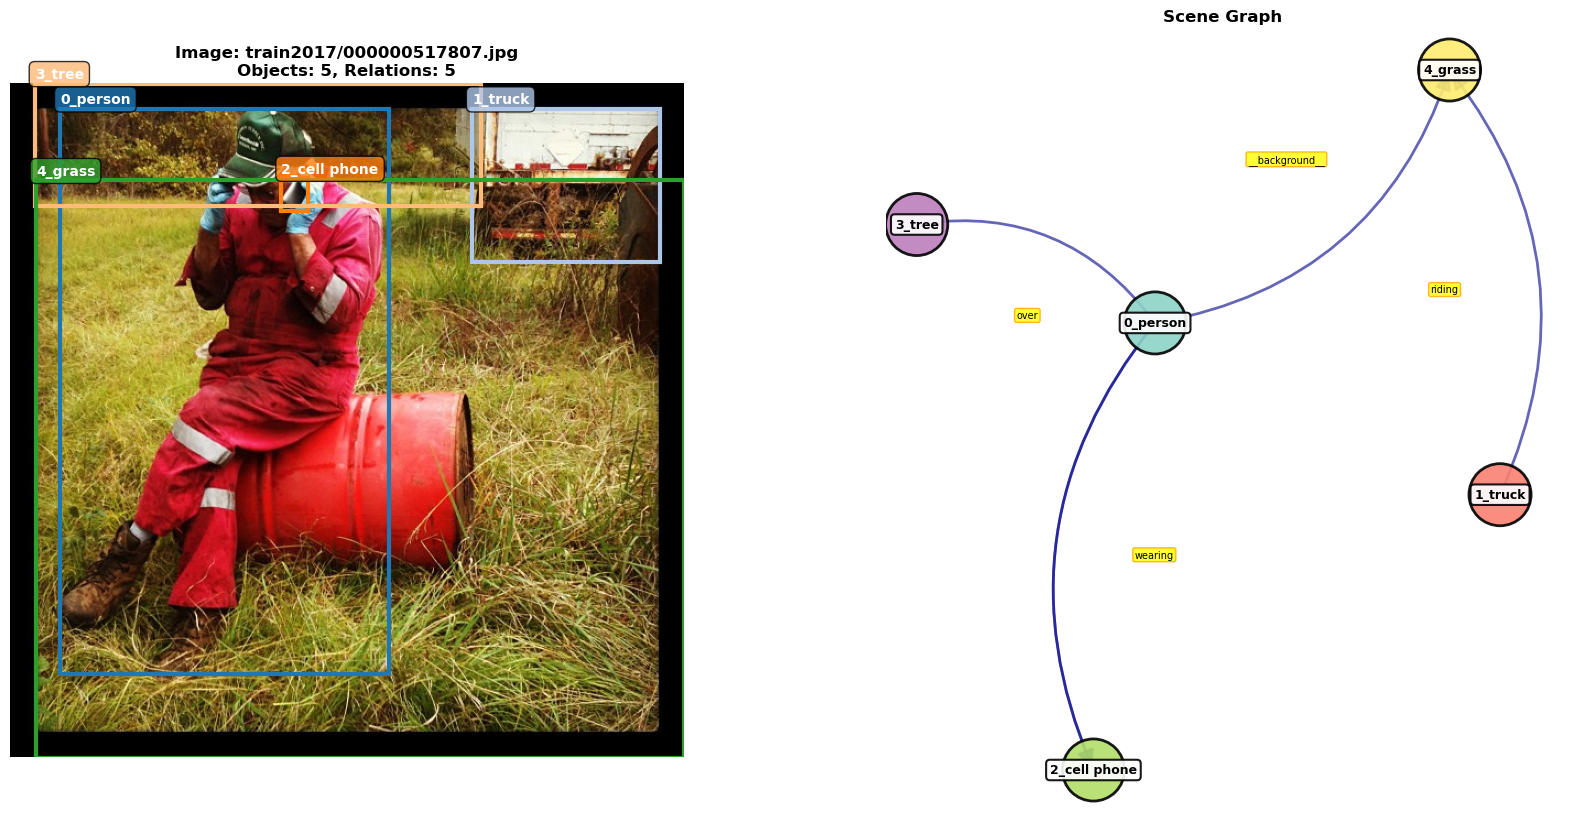


Relationships (Subject -> Predicate -> Object):
  1. [0] person          --[wearing        ]--> [2] cell phone
  2. [0] person          --[wearing        ]--> [2] cell phone
  3. [0] person          --[over           ]--> [3] tree
  4. [0] person          --[__background__ ]--> [4] grass
  5. [1] truck           --[riding         ]--> [4] grass


In [14]:
# Tìm ảnh có predicate cụ thể
target_predicate = "riding"  # Thay đổi predicate này: "holding", "wearing", "sitting on", etc.

pred_id = pred_classes.index(target_predicate) if target_predicate in pred_classes else -1

if pred_id != -1:
    images_with_pred = []
    for img in psg_data['data']:
        for rel in img.get('relations', []):
            if rel[2] == pred_id:
                images_with_pred.append(img)
                break
    
    print(f"Found {len(images_with_pred)} images with predicate '{target_predicate}'")
    
    if images_with_pred:
        visualize_complete_scene(images_with_pred[0], max_relations=30)
else:
    print(f"Predicate '{target_predicate}' not found")

## 12. Phân tích độ phức tạp của Scene Graphs

Top 5 most complex scene graphs:
1. train2017/000000512156.jpg: 57 objects, 28 relations, complexity score: 1596
2. train2017/000000180869.jpg: 43 objects, 36 relations, complexity score: 1548
3. train2017/000000406899.jpg: 35 objects, 42 relations, complexity score: 1470
4. train2017/000000483690.jpg: 45 objects, 31 relations, complexity score: 1395
5. train2017/000000137370.jpg: 35 objects, 36 relations, complexity score: 1260

Visualizing most complex scene graph:


/tmp/ipykernel_1456/1108512443.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


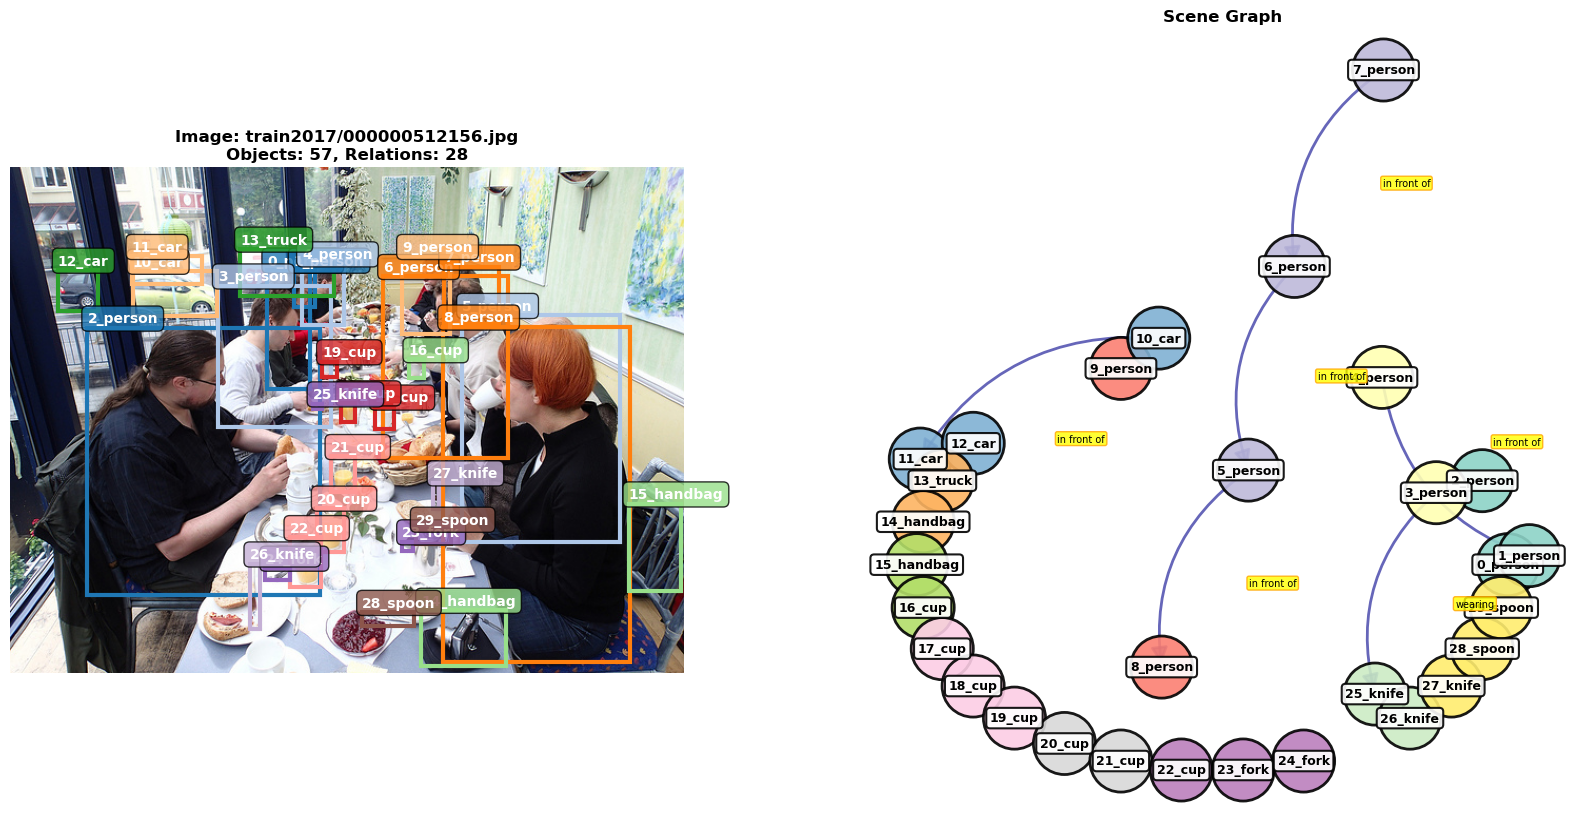


Relationships (Subject -> Predicate -> Object):
  1. [2] person          --[lying on       ]--> [41] chair
  2. [3] person          --[wearing        ]--> [25] knife
  3. [4] person          --[in front of    ]--> [1] person
  4. [5] person          --[in front of    ]--> [8] person
  5. [6] person          --[in front of    ]--> [5] person
  6. [7] person          --[in front of    ]--> [6] person
  7. [8] person          --[lying on       ]--> [42] chair
  8. [10] car             --[in front of    ]--> [11] car
  9. [14] handbag         --[beside         ]--> [52] table
 10. [17] cup             --[beside         ]--> [52] table
 11. [18] cup             --[beside         ]--> [52] table
 12. [20] cup             --[beside         ]--> [52] table
 13. [21] cup             --[beside         ]--> [52] table
 14. [22] cup             --[in front of    ]--> [46] vase
 15. [22] cup             --[beside         ]--> [52] table
 16. [24] fork            --[beside         ]--> [52] table
 

In [15]:
# Tìm các scene graphs phức tạp nhất (nhiều nodes và edges)
complexity_scores = []
for img in psg_data['data']:
    score = len(img['annotations']) * len(img.get('relations', []))
    complexity_scores.append((score, img))

# Sort by complexity
complexity_scores.sort(reverse=True, key=lambda x: x[0])

print("Top 5 most complex scene graphs:")
for i, (score, img) in enumerate(complexity_scores[:5], 1):
    print(f"{i}. {img['file_name']}: "
          f"{len(img['annotations'])} objects, "
          f"{len(img.get('relations', []))} relations, "
          f"complexity score: {score}")

print("\nVisualizing most complex scene graph:")
most_complex = complexity_scores[0][1]
visualize_complete_scene(most_complex, max_relations=40)

## 13. Export Scene Graph dưới dạng JSON

In [16]:
def export_scene_graph_json(img_data, output_file):
    """
    Export scene graph ra file JSON với định dạng dễ đọc
    """
    graph_data = {
        'image': img_data['file_name'],
        'nodes': [],
        'edges': []
    }
    
    # Add nodes
    for idx, ann in enumerate(img_data['annotations']):
        category_id = ann['category_id']
        class_name = obj_classes[category_id] if category_id < len(obj_classes) else f'ID_{category_id}'
        
        graph_data['nodes'].append({
            'id': idx,
            'class': class_name,
            'category_id': category_id,
            'bbox': ann['bbox']
        })
    
    # Add edges
    for rel in img_data.get('relations', []):
        subj_idx, obj_idx, pred_id = rel
        pred_name = pred_classes[pred_id] if pred_id < len(pred_classes) else f'pred_{pred_id}'
        
        if subj_idx < len(img_data['annotations']) and obj_idx < len(img_data['annotations']):
            subj_class = obj_classes[img_data['annotations'][subj_idx]['category_id']]
            obj_class = obj_classes[img_data['annotations'][obj_idx]['category_id']]
            
            graph_data['edges'].append({
                'subject_id': subj_idx,
                'subject_class': subj_class,
                'predicate': pred_name,
                'predicate_id': pred_id,
                'object_id': obj_idx,
                'object_class': obj_class
            })
    
    with open(output_file, 'w') as f:
        json.dump(graph_data, f, indent=2)
    
    print(f"Scene graph exported to {output_file}")

# Export một scene graph mẫu
if good_images:
    export_scene_graph_json(good_images[0], 'sample_scene_graph.json')

Scene graph exported to sample_scene_graph.json
